In [40]:
from datascience import *
import numpy as np


import matplotlib.pyplot as plt

%matplotlib inline

In [41]:
births = Table.read_table("baby.csv")
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


In [42]:
smoking_and_birthweight = births.select("Birth Weight", "Maternal Smoker").select(1, 0)
smoking_and_birthweight

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136
False,138
False,132
False,120
True,143
False,140


In [43]:
smoking_and_birthweight.group("Maternal Smoker")

Maternal Smoker,count
False,715
True,459


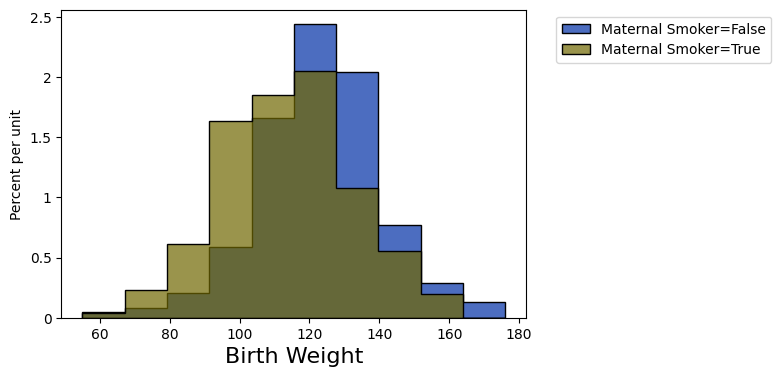

In [44]:
smoking_and_birthweight.hist("Birth Weight", group="Maternal Smoker")

In [45]:
means_table = smoking_and_birthweight.group("Maternal Smoker", collect=np.mean)
means_table

Maternal Smoker,Birth Weight mean
False,123.085
True,113.819


In [46]:
means = means_table.column(1)
observed_difference = means.item(1) - means.item(0)
observed_difference

-9.266142572024918

In [47]:
def differnce_of_means(table, numeric_label, category_label):
    """
        Takes :
            - name of table
            - column label of numeric variable
            - column label of categorical variable

    returns : differnce of Variables of two groups
    """
    # Table with relevant columns
    reduced = table.select(category_label, numeric_label)

    # Table Containing Group Means
    means_table = reduced.group(category_label, collect=np.mean)

    # Array of Groups Table
    means = means_table.column(1)

    return means.item(1) - means.item(0)

In [48]:
differnce_of_means(births, "Birth Weight", "Maternal Smoker")

-9.266142572024918

In [49]:
shuffled_labels = smoking_and_birthweight.sample(with_replacement=False).column("Maternal Smoker")
original_and_shuffled = smoking_and_birthweight.with_column(
    "Shuffled Labels", shuffled_labels
)
original_and_shuffled

Maternal Smoker,Birth Weight,Shuffled Labels
False,120,False
False,113,False
True,128,True
True,108,True
False,136,True
False,138,True
False,132,False
False,120,True
True,143,True
False,140,True


In [50]:
differnce_of_means(original_and_shuffled, "Birth Weight", "Shuffled Labels")

2.6317930435577495

In [51]:
# Permutation Test
def one_simulated_differnce(table, numeric_label, category_label):
    shuffled_labels = table.sample(with_replacement=False).column(category_label)
    shuffled_table = table.select(numeric_label).with_column("Shuffled Label", shuffled_labels)
    return differnce_of_means(shuffled_table, numeric_label, "Shuffled Label")

In [52]:
one_simulated_differnce(births, "Birth Weight", "Maternal Smoker")

1.2259335435805951

In [54]:
diffs = make_array()

for i in range(2500):
    diffs = np.append(diffs, one_simulated_differnce(births, "Birth Weight", "Maternal Smoker"))

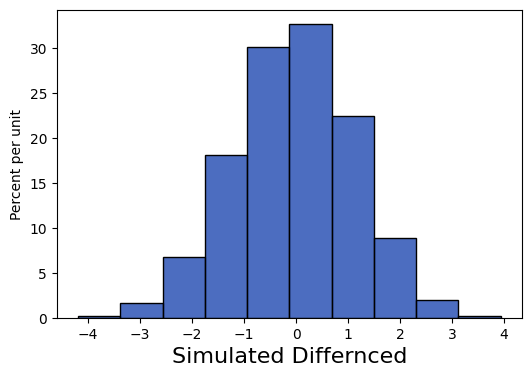

In [57]:
diff_tabl = Table().with_column("Simulated Differnced", diffs)
diff_tabl.hist()

In [58]:
observed_difference

-9.266142572024918